In [1]:
# Importação do dataset e Pandas
import pandas as pd

df = pd.read_excel('data/dados.xlsx')


In [2]:
# Estatística descritiva
df.describe()

,DAP,H,Volume
count,672.000000,672.000000,672.000000
mean,12.047609,9.194107,0.083602
std,4.894081,3.721439,0.079140
min,1.100000,1.500000,0.000435
25%,8.800000,6.400000,0.025726
50%,12.000000,9.150000,0.058092
75%,15.025000,11.900000,0.117383
max,27.692960,21.800000,0.425937


In [3]:
# Verificação de números nulos

df.isnull().sum()

Idade     0
Árvore    0
DAP       0
H         0
Volume    0
dtype: int64

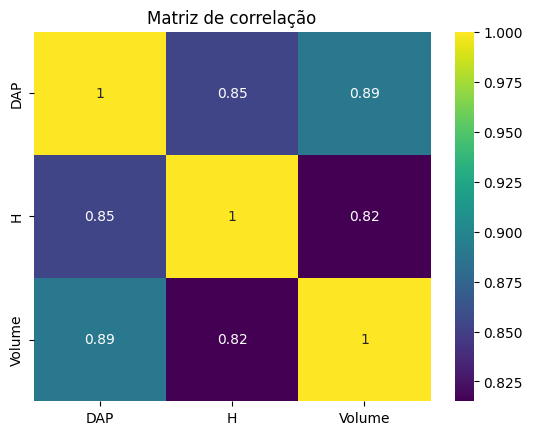

In [4]:
# Análise exploratória utilizando a matriz de correlação

import seaborn as sns
import matplotlib.pyplot as plt

corr = df[['DAP','H','Volume']].corr()

sns.heatmap(corr, annot=True, cmap='viridis')
plt.title("Matriz de correlação")
plt.show()

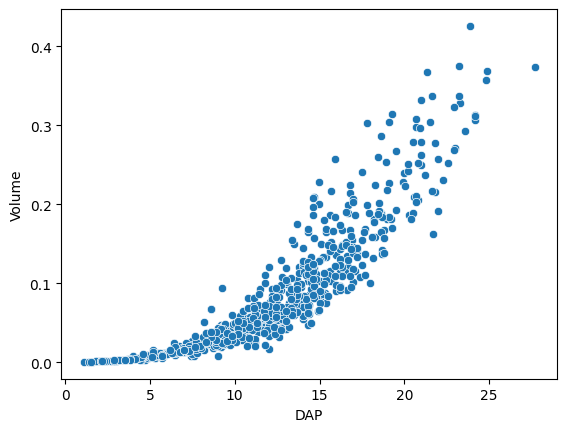

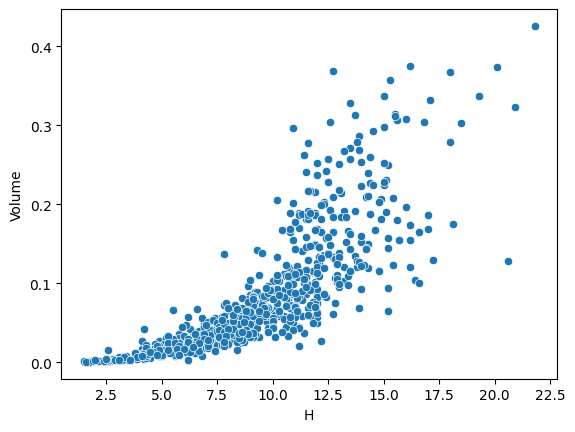

In [5]:
# Relação entre variáveis

sns.scatterplot(data=df, x='DAP', y='Volume')
plt.show()

sns.scatterplot(data=df, x='H', y='Volume')
plt.show()

In [6]:
# Modelo volumétrico: KopezkKopezky-Gehrhardt

## Utiliza apenas DAP -> V = β0 ​+ (β1 * ​DAP ^ 2)

import statsmodels.api as sm

df['DAP2'] = df['DAP']**2

X = df[['DAP2']]
X = sm.add_constant(X)

y = df['Volume']

modelo_kg = sm.OLS(y, X).fit()

modelo_kg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Volume   R-squared:                       0.871
Model:                            OLS   Adj. R-squared:                  0.871
Method:                 Least Squares   F-statistic:                     4534.
Date:                Thu, 12 Mar 2026   Prob (F-statistic):          1.95e-300
Time:                        10:47:29   Log-Likelihood:                 1440.3
No. Observations:                 672   AIC:                            -2877.
Df Residuals:                     670   BIC:                            -2868.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0156      0.002     -8.474      0.000      -0.019      -0.012
DAP2           0.0006   8.71e-06     67.332      0.000       0.001       0.001
==============================================================================
Omnibus:                      153.413   Durbin-Watson:                   1.759
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              463.494
Skew:                           1.097   Prob(JB):                    2.26e-101
Kurtosis:                       6.426   Cond. No.                         353.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [7]:
# Modelo volumétrico: Spurr

## Utiliza apenas DAP -> V = β0 ​+ (β1 * ​DAP ^ 2 * H)

df['DAP2H'] = (df['DAP']**2) * df['H']

X = df[['DAP2H']]
X = sm.add_constant(X)

y = df['Volume']

modelo_spurr = sm.OLS(y, X).fit()

modelo_spurr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Volume   R-squared:                       0.898
Model:                            OLS   Adj. R-squared:                  0.897
Method:                 Least Squares   F-statistic:                     5868.
Date:                Thu, 12 Mar 2026   Prob (F-statistic):               0.00
Time:                        10:47:29   Log-Likelihood:                 1517.0
No. Observations:                 672   AIC:                            -3030.
Df Residuals:                     670   BIC:                            -3021.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0102      0.001      7.419      0.000       0.007       0.013
DAP2H       3.813e-05   4.98e-07     76.600      0.000    3.72e-05    3.91e-05
==============================================================================
Omnibus:                      146.293   Durbin-Watson:                   2.034
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4042.165
Skew:                          -0.172   Prob(JB):                         0.00
Kurtosis:                      15.010   Cond. No.                     3.85e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.85e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [8]:
# Modelo volumétrico: Schumacher-Hall

## Utiliza apenas DAP -> V = β0 ​* DAP ^ β1 * H ^ β2
## Forma linearizada -> ln(V) = β0 ​+ β1 * ​ln(DAP) + β2 * ​ln(H)

import numpy as np

df['lnV'] = np.log(df['Volume'])
df['lnDAP'] = np.log(df['DAP'])
df['lnH'] = np.log(df['H'])

X = df[['lnDAP','lnH']]
X = sm.add_constant(X)

y = df['lnV']

modelo_sh = sm.OLS(y, X).fit()

modelo_sh.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    lnV   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                     7056.
Date:                Thu, 12 Mar 2026   Prob (F-statistic):               0.00
Time:                        10:47:29   Log-Likelihood:                -59.460
No. Observations:                 672   AIC:                             124.9
Df Residuals:                     669   BIC:                             138.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -8.6766      0.049   -178.002      0.000      -8.772      -8.581
lnDAP          1.6373      0.049     33.580      0.000       1.542       1.733
lnH            0.8226      0.051     16.070      0.000       0.722       0.923
==============================================================================
Omnibus:                       49.990   Durbin-Watson:                   1.764
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               98.780
Skew:                          -0.466   Prob(JB):                     3.55e-22
Kurtosis:                       4.630   Cond. No.                         23.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [9]:
# Extraindo as métricas (R², RMSE e MAE) dos modelos

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def avaliar_modelo(modelo, X, y):
    pred = modelo.predict(X)
    r2 = r2_score(y, pred)
    rmse = np.sqrt(mean_squared_error(y, pred))
    mae = mean_absolute_error(y, pred)
    bias = np.mean(pred - y)

    return r2, rmse, mae, bias

# Kopezky-Gehrhardt 
X_kg = sm.add_constant(df[['DAP2']])
y = df['Volume']
r2_kg, rmse_kg, mae_kg, bias_kg = avaliar_modelo(modelo_kg, X_kg, y)

# Spurr 
X_spurr = sm.add_constant(df[['DAP2H']])
r2_spurr, rmse_spurr, mae_spurr, bias_spurr = avaliar_modelo(modelo_spurr, X_spurr, y)

# Schumacher-Hall 
X_sh = sm.add_constant(df[['lnDAP','lnH']])
pred_log = modelo_sh.predict(X_sh)
pred = np.exp(pred_log)
r2_sh = r2_score(y, pred)
rmse_sh = np.sqrt(mean_squared_error(y, pred))
mae_sh = mean_absolute_error(y, pred)
bias_sh = np.mean(pred - y)

resultados = pd.DataFrame({
    "Modelo": [
        "Kopezky-Gehrhardt",
        "Spurr",
        "Schumacher-Hall"
    ],
    "R2":[
        r2_kg,
        r2_spurr,
        r2_sh
    ],
    "RMSE":[
        rmse_kg,
        rmse_spurr,
        rmse_sh
    ],
    "MAE":[
        mae_kg,
        mae_spurr,
        mae_sh
    ],
    "Bias":[
        bias_kg,
        bias_spurr,
        bias_sh
    ]
})

resultados

,Modelo,R2,RMSE,MAE,Bias
0,Kopezky-Gehrhardt,0.871244,0.028376,0.019586,-7.269317e-18
1,Spurr,0.897516,0.025316,0.015816,-2.279922e-17
2,Schumacher-Hall,0.891661,0.026029,0.015716,-5.180148e-03


In [10]:
# Predições de cada modelo

# Kopezky
df["pred_kg"] = modelo_kg.predict(X_kg)

# Spurr
df["pred_spurr"] = modelo_spurr.predict(X_spurr)

# Schumacher-Hall
df["pred_sh"] = pred

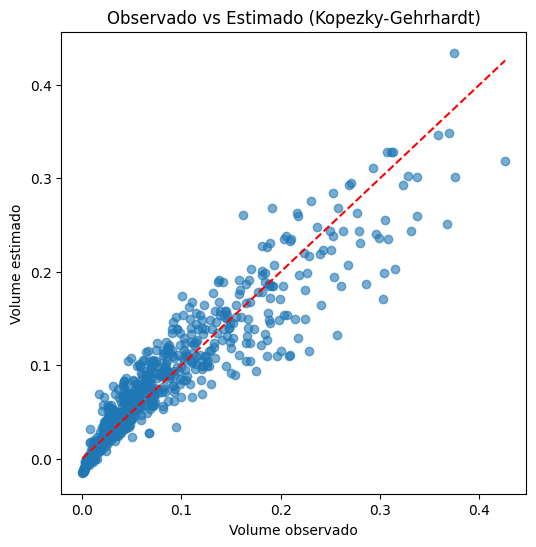

In [11]:
# Gráfico Observado x Estimado (KopeKopezky-Gehrhardtzky)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(df["Volume"], df["pred_kg"], alpha=0.6)

plt.plot(
    [df["Volume"].min(), df["Volume"].max()],
    [df["Volume"].min(), df["Volume"].max()],
    'r--'
)

plt.xlabel("Volume observado")
plt.ylabel("Volume estimado")
plt.title("Observado vs Estimado (Kopezky-Gehrhardt)")

plt.show()

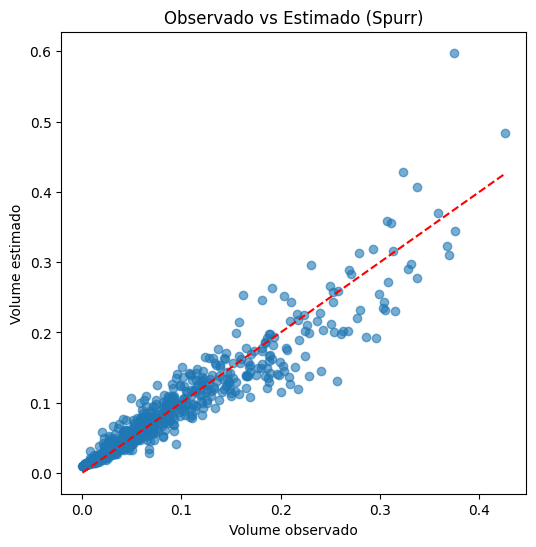

In [12]:
# Gráfico Observado x Estimado (Spurr)

plt.figure(figsize=(6,6))

plt.scatter(df["Volume"], df["pred_spurr"], alpha=0.6)

plt.plot(
    [df["Volume"].min(), df["Volume"].max()],
    [df["Volume"].min(), df["Volume"].max()],
    'r--'
)

plt.xlabel("Volume observado")
plt.ylabel("Volume estimado")
plt.title("Observado vs Estimado (Spurr)")

plt.show()

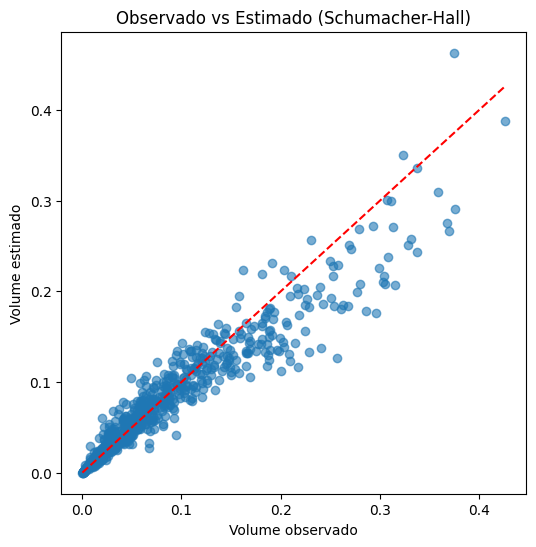

In [13]:
# Gráfico Observado x Estimado (Schumacher-Hall)

plt.figure(figsize=(6,6))

plt.scatter(df["Volume"], df["pred_sh"], alpha=0.6)

plt.plot(
    [df["Volume"].min(), df["Volume"].max()],
    [df["Volume"].min(), df["Volume"].max()],
    'r--'
)

plt.xlabel("Volume observado")
plt.ylabel("Volume estimado")
plt.title("Observado vs Estimado (Schumacher-Hall)")

plt.show()

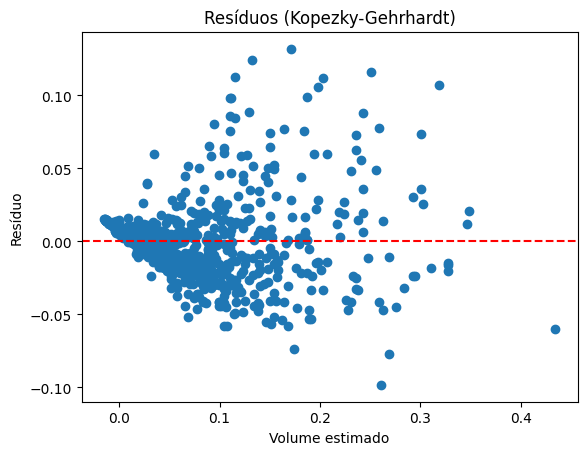

In [14]:
# Gráfico de resíduos (Kopezky-Gehrhardt)

df["res_kg"] = df["Volume"] - df["pred_kg"]

plt.scatter(df["pred_kg"], df["res_kg"])

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Volume estimado")
plt.ylabel("Resíduo")

plt.title("Resíduos (Kopezky-Gehrhardt)")

plt.show()

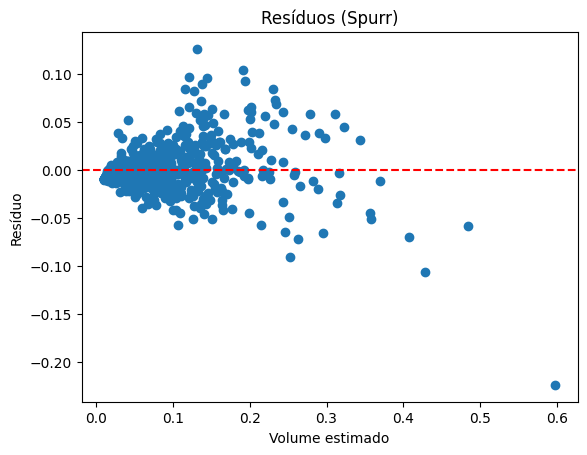

In [15]:
# Gráfico de resíduos (Spurr)

df["res_spurr"] = df["Volume"] - df["pred_spurr"]

plt.scatter(df["pred_spurr"], df["res_spurr"])

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Volume estimado")
plt.ylabel("Resíduo")

plt.title("Resíduos (Spurr)")

plt.show()

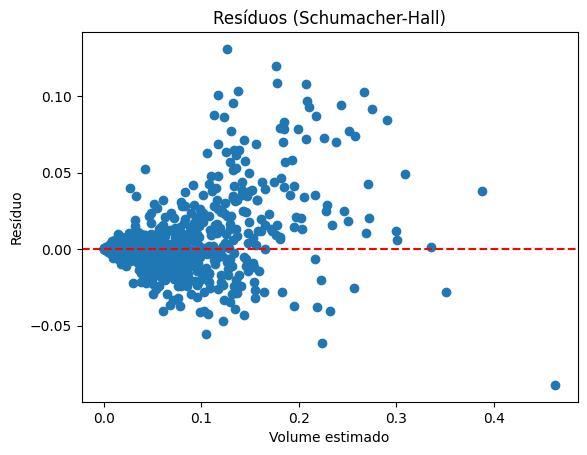

In [16]:
# Gráfico de resíduos (Schumacher-Hall)

df["res_sh"] = df["Volume"] - df["pred_sh"]

plt.scatter(df["pred_sh"], df["res_sh"])

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Volume estimado")
plt.ylabel("Resíduo")

plt.title("Resíduos (Schumacher-Hall)")

plt.show()

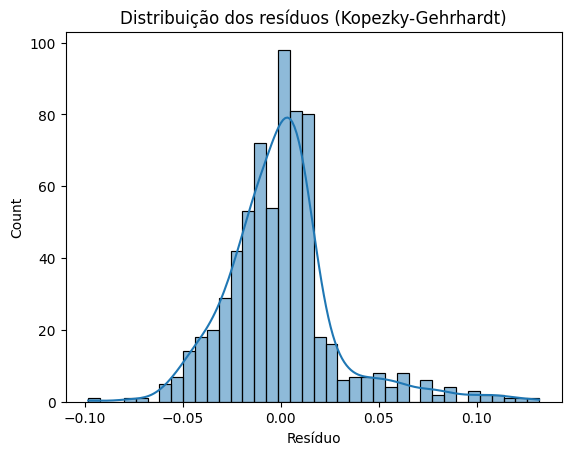

In [17]:
# Histograma de resíduos (Kopezky-Gehrhardt)

sns.histplot(df["res_kg"], kde=True)

plt.title("Distribuição dos resíduos (Kopezky-Gehrhardt)")
plt.xlabel("Resíduo")

plt.show()

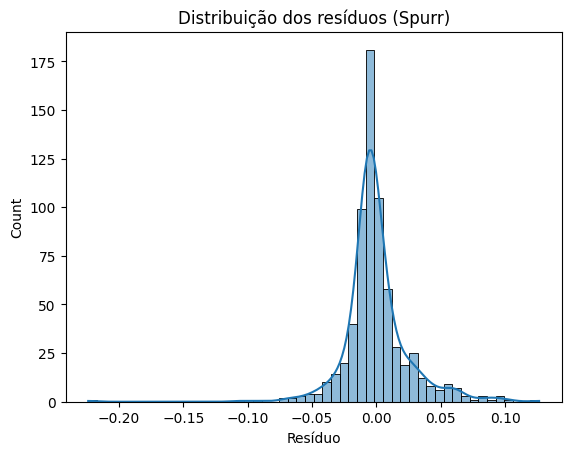

In [18]:
# Histograma de resíduos (Spurr)

sns.histplot(df["res_spurr"], kde=True)

plt.title("Distribuição dos resíduos (Spurr)")
plt.xlabel("Resíduo")

plt.show()

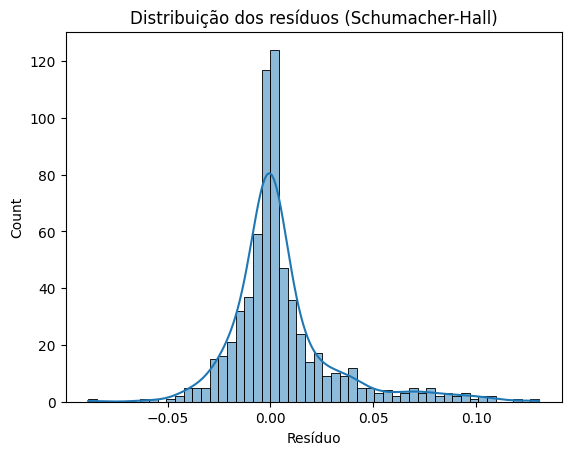

In [19]:
# Histograma de resíduos (Schumacher-Hall)

sns.histplot(df["res_sh"], kde=True)

plt.title("Distribuição dos resíduos (Schumacher-Hall)")
plt.xlabel("Resíduo")

plt.show()

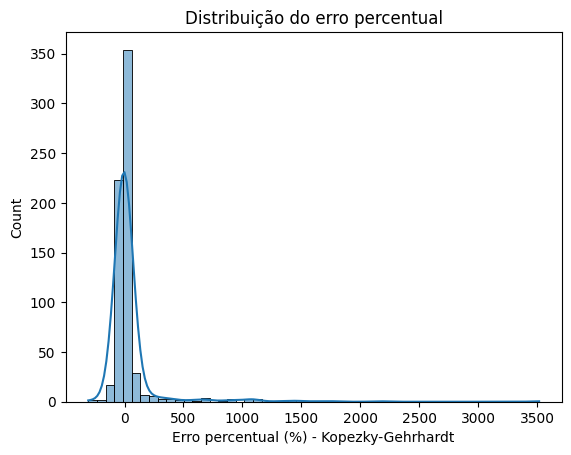

In [20]:
# Erro percentual (Kopezky-Gehrhardt)

df["erro_pct_kg"] = ((df["Volume"] - df["pred_kg"]) / df["Volume"]) * 100

sns.histplot(df["erro_pct_kg"], kde=True)

plt.xlabel("Erro percentual (%) - Kopezky-Gehrhardt")
plt.title("Distribuição do erro percentual")

plt.show()

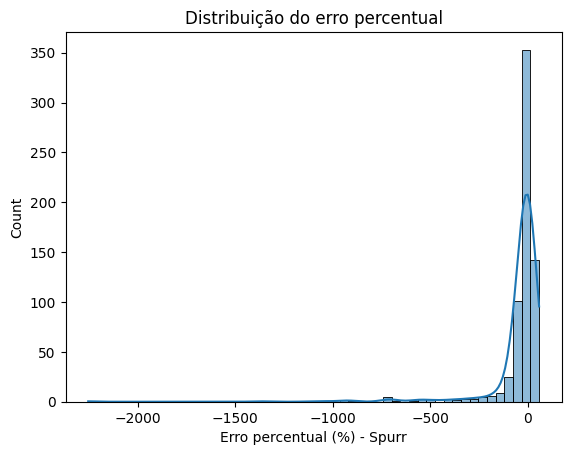

In [21]:
# Erro percentual (Spurr)

df["erro_pct_spurr"] = ((df["Volume"] - df["pred_spurr"]) / df["Volume"]) * 100

sns.histplot(df["erro_pct_spurr"], kde=True)

plt.xlabel("Erro percentual (%) - Spurr")
plt.title("Distribuição do erro percentual")

plt.show()

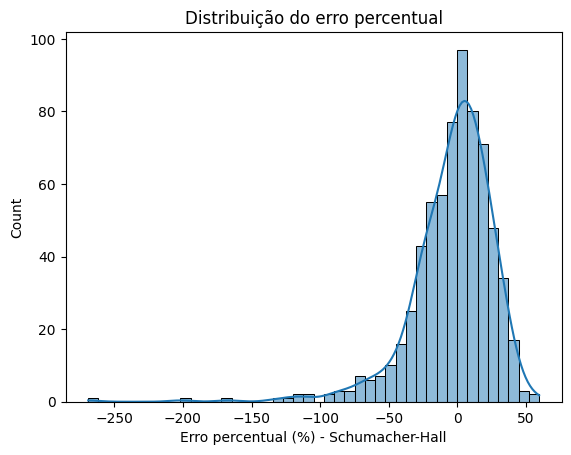

In [22]:
# Erro percentual (Schumacher-Hall)

df["erro_pct_sh"] = ((df["Volume"] - df["pred_sh"]) / df["Volume"]) * 100

sns.histplot(df["erro_pct_sh"], kde=True)

plt.xlabel("Erro percentual (%) - Schumacher-Hall")
plt.title("Distribuição do erro percentual")

plt.show()

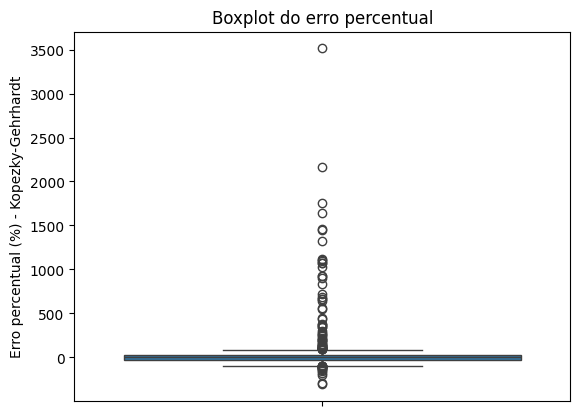

In [23]:
# Boxplot do erro (Kopezky-Gehrhardt)

sns.boxplot(y=df["erro_pct_kg"])

plt.ylabel("Erro percentual (%) - Kopezky-Gehrhardt")
plt.title("Boxplot do erro percentual")

plt.show()

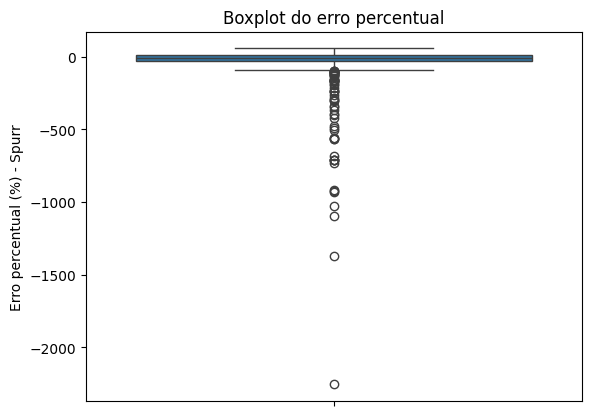

In [24]:
# Boxplot do erro (Spurr)

sns.boxplot(y=df["erro_pct_spurr"])

plt.ylabel("Erro percentual (%) - Spurr")
plt.title("Boxplot do erro percentual")

plt.show()

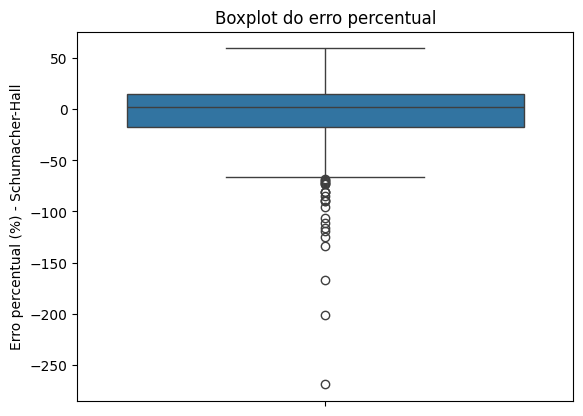

In [25]:
# Boxplot do erro (Schumacher-Hall)

sns.boxplot(y=df["erro_pct_sh"])

plt.ylabel("Erro percentual (%) - Schumacher-Hall")
plt.title("Boxplot do erro percentual")

plt.show()

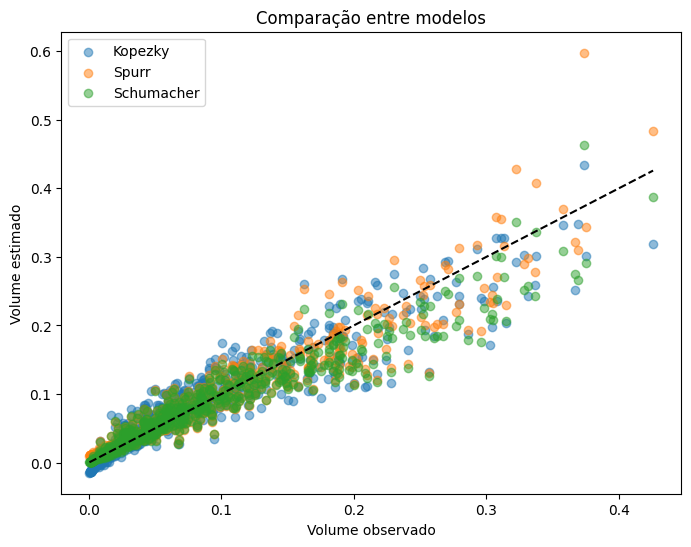

In [26]:
# Comparação entre os modelos

plt.figure(figsize=(8,6))

plt.scatter(df["Volume"], df["pred_kg"], label="Kopezky", alpha=0.5)
plt.scatter(df["Volume"], df["pred_spurr"], label="Spurr", alpha=0.5)
plt.scatter(df["Volume"], df["pred_sh"], label="Schumacher", alpha=0.5)

plt.plot(
    [df["Volume"].min(), df["Volume"].max()],
    [df["Volume"].min(), df["Volume"].max()],
    'k--'
)

plt.legend()

plt.xlabel("Volume observado")
plt.ylabel("Volume estimado")

plt.title("Comparação entre modelos")

plt.show()

In [27]:
# Preparando os dados para os algoritmos de IA

X = df[['DAP','H']]
y = df['Volume']

In [28]:
# Separação de conjuntos de treino e teste (70/30)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42
)

In [29]:
# Random Forest

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [30]:
# Support Vector Machine (SVR)

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVR(kernel='rbf'))
])

svm_model.fit(X_train, y_train)

pred_svm = svm_model.predict(X_test)

In [31]:
# Rede Neural (MLP)

from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(
    hidden_layer_sizes=(50,50),
    max_iter=5000,
    random_state=42
)

mlp.fit(X_train, y_train)

pred_mlp = mlp.predict(X_test)

In [32]:
# XGBoost

from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

In [33]:
# Definindo a função de avaliação

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

def avaliar_ml(y_true, pred):
    r2 = r2_score(y_true, pred)
    rmse = np.sqrt(mean_squared_error(y_true, pred))
    mae = mean_absolute_error(y_true, pred)
    bias = np.mean(pred - y_true)

    return r2, rmse, mae, bias

In [34]:
# Avaliação dos modelos de IA

r2_rf, rmse_rf, mae_rf, bias_rf = avaliar_ml(y_test, pred_rf)
r2_svm, rmse_svm, mae_svm, bias_svm = avaliar_ml(y_test, pred_svm)
r2_mlp, rmse_mlp, mae_mlp, bias_mlp = avaliar_ml(y_test, pred_mlp)
r2_xgb, rmse_xgb, mae_xgb, bias_xgb = avaliar_ml(y_test, pred_xgb)

In [35]:
resultados_ml = pd.DataFrame({
    "Modelo":[
        "Random Forest",
        "SVM",
        "Neural Network",
        "XGBoost"
    ],
    "R2":[
        r2_rf,
        r2_svm,
        r2_mlp,
        r2_xgb
    ],
    "RMSE":[
        rmse_rf,
        rmse_svm,
        rmse_mlp,
        rmse_xgb
    ],
    "MAE":[
        mae_rf,
        mae_svm,
        mae_mlp,
        mae_xgb
    ],
    "Bias":[
        bias_rf,
        bias_svm,
        bias_mlp,
        bias_xgb
    ]
})

resultados_ml.round(4)

,Modelo,R2,RMSE,MAE,Bias
0,Random Forest,0.9118,0.0241,0.0155,-0.0006
1,SVM,0.2828,0.0687,0.0632,0.0563
2,Neural Network,0.8005,0.0362,0.0272,-0.0017
3,XGBoost,0.8962,0.0261,0.0162,0.0006


In [36]:
# Comparação final (tradicional X IA)

resultados_total = pd.concat([resultados, resultados_ml])
resultados_total

,Modelo,R2,RMSE,MAE,Bias
0,Kopezky-Gehrhardt,0.871244,0.028376,0.019586,-7.269317e-18
1,Spurr,0.897516,0.025316,0.015816,-2.279922e-17
2,Schumacher-Hall,0.891661,0.026029,0.015716,-5.180148e-03
0,Random Forest,0.911807,0.024074,0.015469,-6.043079e-04
1,SVM,0.282766,0.068653,0.063201,5.629311e-02
2,Neural Network,0.800537,0.036204,0.027179,-1.697692e-03
3,XGBoost,0.896174,0.026120,0.016204,5.823878e-04


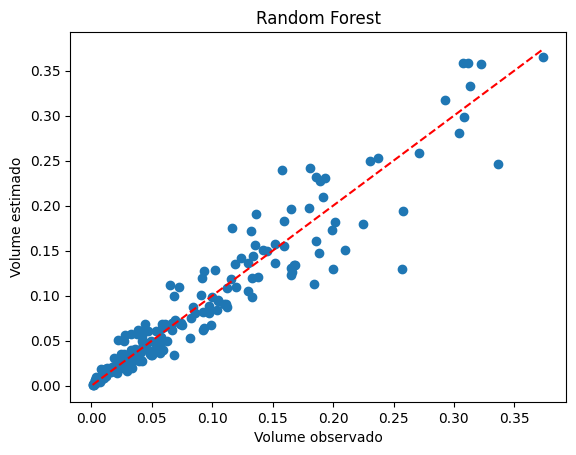

In [37]:
# Observado vs Estimado (Random Forest)

plt.scatter(y_test, pred_rf)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Volume observado")
plt.ylabel("Volume estimado")

plt.title("Random Forest")

plt.show()

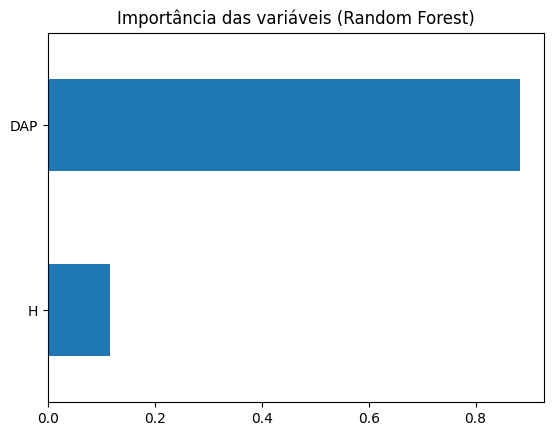

In [49]:
# Importância das variáveis (Random Forest)

importances = rf.feature_importances_
feat_import = pd.Series(importances, index=X.columns)
feat_import.sort_values().plot(kind='barh')

plt.title("Importância das variáveis (Random Forest)")
plt.show()

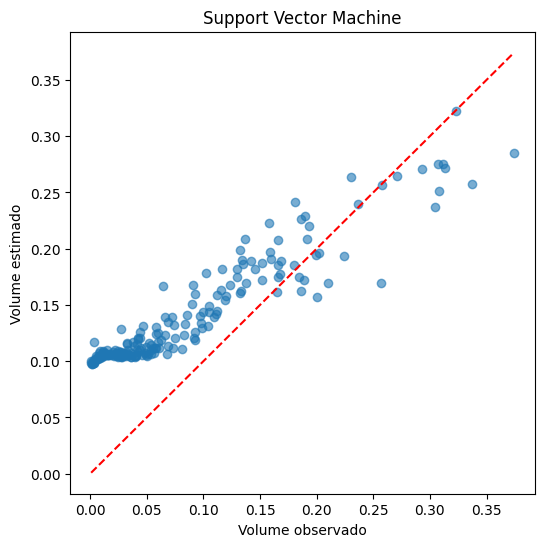

In [42]:
# Observado vs Estimado (Support Vector Machine)

plt.figure(figsize=(6,6))

plt.scatter(y_test, pred_svm, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Volume observado")
plt.ylabel("Volume estimado")

plt.title("Support Vector Machine")

plt.show()

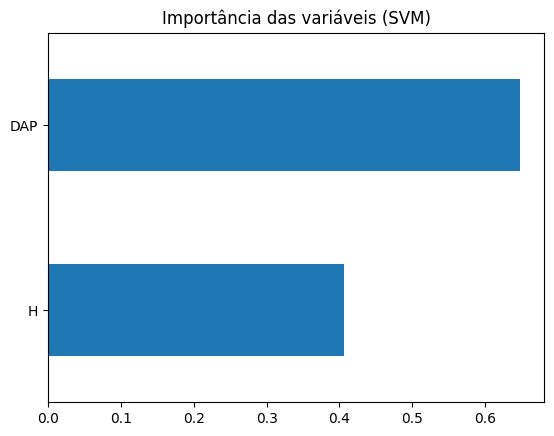

In [43]:
# Importância das variáveis (Support Vector Machine)

from sklearn.inspection import permutation_importance

result = permutation_importance(
    svm_model,
    X_test,
    y_test,
    n_repeats=30,
    random_state=42
)

importances = pd.Series(result.importances_mean, index=X.columns)

importances.sort_values().plot(kind="barh")

plt.title("Importância das variáveis (SVM)")

plt.show()

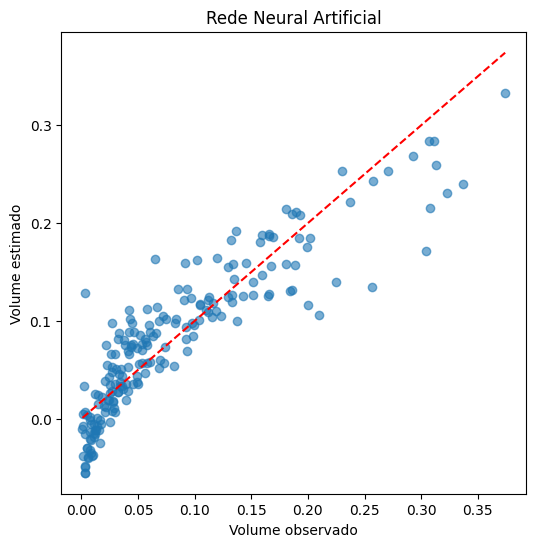

In [50]:
# Observado vs Estimado (Rede Neural)

plt.figure(figsize=(6,6))

plt.scatter(y_test, pred_mlp, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Volume observado")
plt.ylabel("Volume estimado")

plt.title("Rede Neural Artificial")

plt.show()

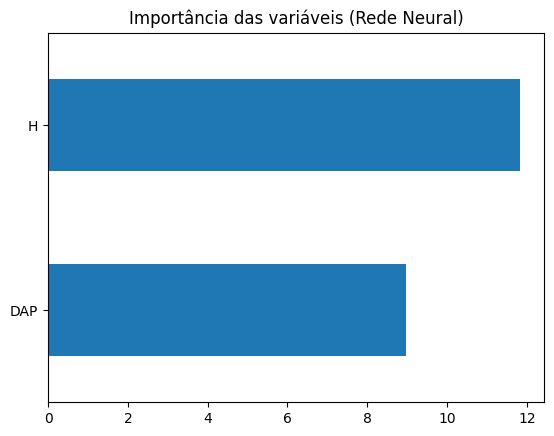

In [51]:
# Importância das variáveis (Rede Neural)

result = permutation_importance(
    mlp,
    X_test,
    y_test,
    n_repeats=30,
    random_state=42
)

importances = pd.Series(result.importances_mean, index=X.columns)

importances.sort_values().plot(kind="barh")

plt.title("Importância das variáveis (Rede Neural)")

plt.show()

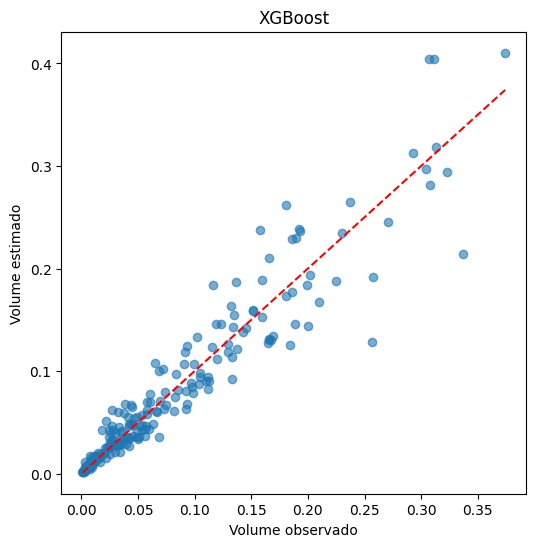

In [52]:
# Observado vs Estimado (XGBoost)

plt.figure(figsize=(6,6))

plt.scatter(y_test, pred_xgb, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Volume observado")
plt.ylabel("Volume estimado")

plt.title("XGBoost")

plt.show()

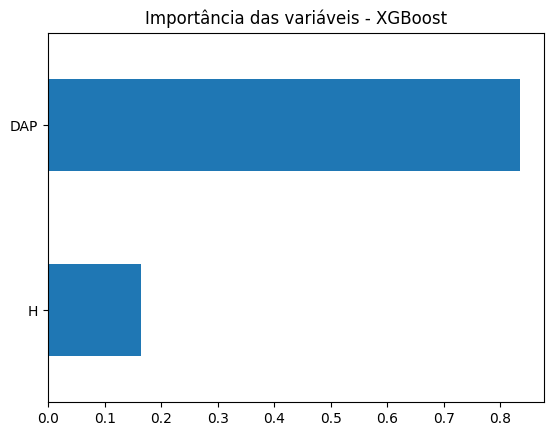

In [54]:
# Importância das variáveis (XGBoost)

importances = xgb.feature_importances_
feat_import = pd.Series(importances, index=X.columns)
feat_import.sort_values().plot(kind='barh')

plt.title("Importância das variáveis - XGBoost")

plt.show()